In [ ]:
import json
import os
import sys
from glob import glob
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src._config import DEFAULT_N_JOBS, DEFAULT_RESULTS_DIR

for _var in (
    "OMP_NUM_THREADS",
    "MKL_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
):
    os.environ[_var] = str(DEFAULT_N_JOBS)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Toggle to `True` to save outputs
save_output = False

ROOT = Path.cwd().parent
EVAL_DIR = ROOT / DEFAULT_RESULTS_DIR / "eval_classification"
OUT_IMG = ROOT / "img/"
OUT_IMG.mkdir(parents=True, exist_ok=True)

plt.style.use(".matplotlib/paper.mplstyle")

for cfg_file in glob(f"{EVAL_DIR}/*/cfg.json"):
    with open(cfg_file) as f:
        cfg = json.load(f)
    print(f"{cfg_file}: model={cfg['model']}, input={cfg['input']}")

In [2]:
PANEL_A_RUNS = {
    "features_mlp": f"{EVAL_DIR}/20260916_123403_mlp",
    "dinov3": f"{EVAL_DIR}/20260916_093850_temporal_cnn2",
    "vjepa2": f"{EVAL_DIR}/20260916_101306_temporal_cnn2",
    "vjepa21": f"{EVAL_DIR}/20260916_102516_temporal_cnn2",
    "videoprism": f"{EVAL_DIR}/20260916_095809_temporal_cnn2",
    "best": f"{EVAL_DIR}/20260916_110657_temporal_cnn2",
}

summary_data = {}
for model, run_dir in PANEL_A_RUNS.items():
    df = pd.read_csv(f"{run_dir}/loco_summary.csv", index_col=0)

    cms = np.load(f"{run_dir}/loco_test_confusion_matrices.npy")  # (5, 3, 3)
    worm_f1s, loco_f1s = [], []
    for fold_cm in cms:
        for cls_idx, f1_list in [(1, worm_f1s), (2, loco_f1s)]:
            tp = fold_cm[cls_idx, cls_idx]
            col_sum = fold_cm[:, cls_idx].sum()
            row_sum = fold_cm[cls_idx, :].sum()
            prec = tp / col_sum if col_sum > 0 else 0
            rec = tp / row_sum if row_sum > 0 else 0
            f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
            f1_list.append(f1)

    summary_data[model] = {
        "test_macro_f1_pooled": df.loc["POOLED", "test_macro_f1"],
        "test_macro_f1_std": df.loc["STD", "test_macro_f1"],
        "test_object_f1_pooled": np.mean(worm_f1s),
        "test_object_f1_std": np.std(worm_f1s, ddof=1),
        "test_locomotor_f1_pooled": np.mean(loco_f1s),
        "test_locomotor_f1_std": np.std(loco_f1s, ddof=1),
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient="index").reset_index(
    names="model"
)
summary_df

,model,test_macro_f1_pooled,test_macro_f1_std,test_object_f1_pooled,test_object_f1_std,test_locomotor_f1_pooled,test_locomotor_f1_std
0,features_mlp,0.731099,0.044189,0.489007,0.115268,0.734893,0.056050
1,dinov3,0.739049,0.068110,0.496296,0.158997,0.766383,0.074024
2,vjepa2,0.740501,0.041207,0.473098,0.120138,0.770157,0.060797
3,vjepa21,0.770916,0.053175,0.568502,0.129421,0.758854,0.054198
4,videoprism,0.755693,0.053634,0.526977,0.139849,0.767118,0.056951
5,best,0.776742,0.057876,0.582256,0.141582,0.755720,0.067706


In [3]:
summary_df_melt = summary_df.melt(
    id_vars=["model"],
    value_vars=[
        "test_macro_f1_pooled",
        "test_object_f1_pooled",
        "test_locomotor_f1_pooled",
    ],
    var_name="metric",
    value_name="value",
)

summary_df_melt

,model,metric,value
0,features_mlp,test_macro_f1_pooled,0.731099
1,dinov3,test_macro_f1_pooled,0.739049
2,vjepa2,test_macro_f1_pooled,0.740501
3,vjepa21,test_macro_f1_pooled,0.770916
4,videoprism,test_macro_f1_pooled,0.755693
5,best,test_macro_f1_pooled,0.776742
6,features_mlp,test_object_f1_pooled,0.489007
7,dinov3,test_object_f1_pooled,0.496296
8,vjepa2,test_object_f1_pooled,0.473098
9,vjepa21,test_object_f1_pooled,0.568502


/tmp/ipykernel_1621596/3823087513.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


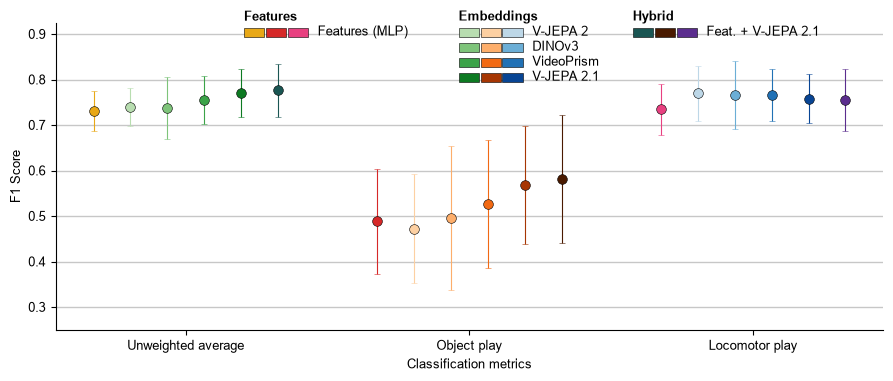

In [ ]:
from matplotlib.patches import Patch

MODEL_ORDER = ["features_mlp", "vjepa2", "dinov3", "videoprism", "vjepa21", "best"]
METRIC_ORDER = [
    "test_macro_f1_pooled",
    "test_object_f1_pooled",
    "test_locomotor_f1_pooled",
]
METRIC_NICE = {
    "test_macro_f1_pooled": "Unweighted average",
    "test_object_f1_pooled": "Object play",
    "test_locomotor_f1_pooled": "Locomotor play",
}
SD_COL = {
    "test_macro_f1_pooled": "test_macro_f1_std",
    "test_object_f1_pooled": "test_object_f1_std",
    "test_locomotor_f1_pooled": "test_locomotor_f1_std",
}
MODEL_NICE = {
    "features_mlp": "Features (MLP)",
    "dinov3": "DINOv3",
    "vjepa2": "V-JEPA 2",
    "vjepa21": "V-JEPA 2.1",
    "videoprism": "VideoPrism",
    "best": "Feat. + V-JEPA 2.1",
}

BAR_COLORS = {
    "test_macro_f1_pooled": {
        "features_mlp": "#E8A817",
        "vjepa2": "#B8DDB0",
        "dinov3": "#7EC47A",
        "videoprism": "#3BA348",
        "vjepa21": "#0D7A22",
        "best": "#1A5653",
    },
    "test_object_f1_pooled": {
        "features_mlp": "#D62828",
        "vjepa2": "#FDD0A2",
        "dinov3": "#FDAE6B",
        "videoprism": "#F16913",
        "vjepa21": "#A63603",
        "best": "#4A1A00",
    },
    "test_locomotor_f1_pooled": {
        "features_mlp": "#E84080",
        "vjepa2": "#BDD7E7",
        "dinov3": "#6BAED6",
        "videoprism": "#2171B5",
        "vjepa21": "#084594",
        "best": "#5B2D8E",
    },
}

# ── Plot ─────────────────────────────────────────────────────────
sdf = summary_df.set_index("model")
n_metrics = len(METRIC_ORDER)
n_models = len(MODEL_ORDER)
bar_width = 0.13

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(9, 3.75))
    x_group = np.arange(n_metrics)

    for j, metric in enumerate(METRIC_ORDER):
        for i, model in enumerate(MODEL_ORDER):
            val = sdf.loc[model, metric]
            sd = sdf.loc[model, SD_COL[metric]]
            x_pos = j + (i - (n_models - 1) / 2) * bar_width

            ax.errorbar(
                x_pos,
                val,
                yerr=sd,
                fmt="o",
                color=BAR_COLORS[metric][model],
                markeredgecolor="black",
                markeredgewidth=0.4,
                markersize=7,
                capsize=2,
                elinewidth=0.8,
            )

    ax.set_xticks(x_group)
    ax.set_xticklabels([METRIC_NICE[m] for m in METRIC_ORDER])
    ax.set_ylabel("F1 Score")
    ax.set_ylim(0, 1.05)

    from matplotlib.legend_handler import HandlerTuple

    handles = [
        tuple(
            Patch(facecolor=BAR_COLORS[metric][m], edgecolor="none")
            for metric in METRIC_ORDER
        )
        for m in MODEL_ORDER
    ]
    # Legend below plot — 3 columns with headers
    columns = [
        ("Features", [("features_mlp", MODEL_NICE["features_mlp"])]),
        (
            "Embeddings",
            [(m, MODEL_NICE[m]) for m in ["vjepa2", "dinov3", "videoprism", "vjepa21"]],
        ),
        ("Hybrid", [("best", MODEL_NICE["best"])]),
    ]

    leg_ax = fig.add_axes([0.05, 0.8, 0.9, 0.2])
    leg_ax.set_xlim(0, 1)
    leg_ax.set_ylim(0, 1)
    leg_ax.axis("off")

    col_x = [0.25, 0.515, 0.73]
    row_height = 0.2
    swatch_w = 0.025
    swatch_gap = 0.002

    for col_idx, (header, entries) in enumerate(columns):
        x = col_x[col_idx]
        y_start = 0.9
        leg_ax.text(
            x,
            y_start,
            header,
            fontweight="bold",
            va="center",
            transform=leg_ax.transAxes,
        )
        for row_idx, (model_key, label) in enumerate(entries):
            y = y_start - (row_idx + 1) * row_height
            # Draw one swatch per metric
            for k, metric in enumerate(METRIC_ORDER):
                rect = plt.Rectangle(
                    (x + k * (swatch_w + swatch_gap), y - 0.06),
                    swatch_w,
                    0.12,
                    facecolor=BAR_COLORS[metric][model_key],
                    edgecolor="black",
                    linewidth=0.4,
                    transform=leg_ax.transAxes,
                    clip_on=False,
                )
                leg_ax.add_patch(rect)
            leg_ax.text(
                x + 3 * (swatch_w + swatch_gap) + 0.01,
                y,
                label,
                va="center",
                transform=leg_ax.transAxes,
            )

    ax.set_ylim(bottom=0.25, top=0.925)
    ax.set_xlabel("Classification metrics")
    ax.grid(axis="y", linewidth=1, alpha=0.7)
    sns.despine()
    plt.tight_layout()
    if save_output:
        plt.savefig(OUT_IMG / "fig3_metrics.pdf", dpi=300)
        plt.savefig(OUT_IMG / "fig3_metrics.png", dpi=300)
    plt.show()

/tmp/ipykernel_1621596/4226086969.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


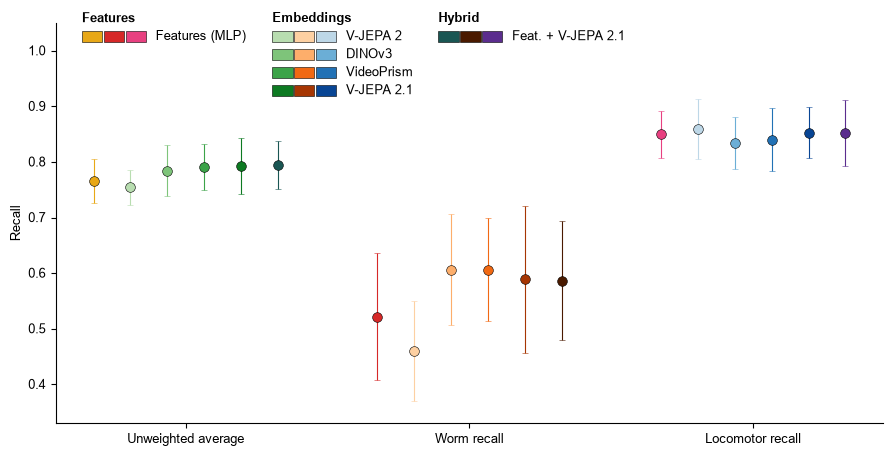

,model,test_uar_pooled,test_uar_std,test_object_recall_pooled,test_object_recall_std,test_locomotor_recall_pooled,test_locomotor_recall_std
0,features_mlp,0.765873,0.039710,0.5215,0.1139,0.8496,0.0425
1,dinov3,0.784140,0.046199,0.6064,0.1004,0.8338,0.0466
2,vjepa2,0.754107,0.031456,0.4598,0.0894,0.8587,0.0541
3,vjepa21,0.793020,0.050750,0.5890,0.1326,0.8528,0.0461
4,videoprism,0.790693,0.041784,0.6060,0.0926,0.8404,0.0570
5,best,0.794873,0.043383,0.5865,0.1074,0.8518,0.0590


In [ ]:
# ── UAR (unweighted average recall) variant of fig3_metrics ─────
# UAR = mean of per-class recalls.  Computed per fold, then mean ± std across folds.

uar_data = {}
for model, run_dir in PANEL_A_RUNS.items():
    with open(f"{run_dir}/loco_test_recall.txt") as f:
        lines = f.readlines()

    # Parse per-fold recalls (lines 1–5) for all three classes
    fold_uars = []
    for line in lines[1:6]:
        parts = line.split()[1:]  # skip fold label
        recalls = [float(x) for x in parts]  # [none, worm, locomotor]
        fold_uars.append(np.mean(recalls))

    mean_recall_values = [float(x) for x in lines[6].split()[1:]]

    uar_data[model] = {
        "test_uar_pooled": np.mean(fold_uars),
        "test_uar_std": np.std(fold_uars, ddof=1),
        "test_object_recall_pooled": mean_recall_values[1],
        "test_object_recall_std": float(lines[7].split()[2]),
        "test_locomotor_recall_pooled": mean_recall_values[2],
        "test_locomotor_recall_std": float(lines[7].split()[3]),
    }

uar_df = pd.DataFrame.from_dict(uar_data, orient="index").reset_index(names="model")

# ── Plot ────────────────────────────────────────────────────────
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

MODEL_ORDER = ["features_mlp", "vjepa2", "dinov3", "videoprism", "vjepa21", "best"]
METRIC_ORDER_UAR = [
    "test_uar_pooled",
    "test_object_recall_pooled",
    "test_locomotor_recall_pooled",
]
METRIC_NICE_UAR = {
    "test_uar_pooled": "Unweighted average",
    "test_object_recall_pooled": "Worm recall",
    "test_locomotor_recall_pooled": "Locomotor recall",
}
SD_COL_UAR = {
    "test_uar_pooled": "test_uar_std",
    "test_object_recall_pooled": "test_object_recall_std",
    "test_locomotor_recall_pooled": "test_locomotor_recall_std",
}

BAR_COLORS_UAR = {
    "test_uar_pooled": {
        "features_mlp": "#E8A817",
        "vjepa2": "#B8DDB0",
        "dinov3": "#7EC47A",
        "videoprism": "#3BA348",
        "vjepa21": "#0D7A22",
        "best": "#1A5653",
    },
    "test_object_recall_pooled": {
        "features_mlp": "#D62828",
        "vjepa2": "#FDD0A2",
        "dinov3": "#FDAE6B",
        "videoprism": "#F16913",
        "vjepa21": "#A63603",
        "best": "#4A1A00",
    },
    "test_locomotor_recall_pooled": {
        "features_mlp": "#E84080",
        "vjepa2": "#BDD7E7",
        "dinov3": "#6BAED6",
        "videoprism": "#2171B5",
        "vjepa21": "#084594",
        "best": "#5B2D8E",
    },
}

sdf_uar = uar_df.set_index("model")
n_metrics = len(METRIC_ORDER_UAR)
n_models = len(MODEL_ORDER)
bar_width = 0.13

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    x_group = np.arange(n_metrics)

    for j, metric in enumerate(METRIC_ORDER_UAR):
        for i, model in enumerate(MODEL_ORDER):
            val = sdf_uar.loc[model, metric]
            sd = sdf_uar.loc[model, SD_COL_UAR[metric]]
            x_pos = j + (i - (n_models - 1) / 2) * bar_width

            ax.errorbar(
                x_pos,
                val,
                yerr=sd,
                fmt="o",
                color=BAR_COLORS_UAR[metric][model],
                markeredgecolor="black",
                markeredgewidth=0.4,
                markersize=7,
                capsize=2,
                elinewidth=0.8,
            )

    ax.set_xticks(x_group)
    ax.set_xticklabels([METRIC_NICE_UAR[m] for m in METRIC_ORDER_UAR])
    ax.set_ylabel("Recall")
    ax.set_ylim(0, 1.05)

    handles = [
        tuple(
            Patch(facecolor=BAR_COLORS_UAR[metric][m], edgecolor="none")
            for metric in METRIC_ORDER_UAR
        )
        for m in MODEL_ORDER
    ]

    columns = [
        ("Features", [("features_mlp", MODEL_NICE["features_mlp"])]),
        (
            "Embeddings",
            [(m, MODEL_NICE[m]) for m in ["vjepa2", "dinov3", "videoprism", "vjepa21"]],
        ),
        ("Hybrid", [("best", MODEL_NICE["best"])]),
    ]

    leg_ax = fig.add_axes([0.05, 0.8, 0.9, 0.2])
    leg_ax.set_xlim(0, 1)
    leg_ax.set_ylim(0, 1)
    leg_ax.axis("off")

    col_x = [0.05, 0.285, 0.49]
    row_height = 0.2
    swatch_w = 0.025
    swatch_gap = 0.002

    for col_idx, (header, entries) in enumerate(columns):
        x = col_x[col_idx]
        y_start = 0.9
        leg_ax.text(
            x,
            y_start,
            header,
            fontweight="bold",
            va="center",
            transform=leg_ax.transAxes,
        )
        for row_idx, (model_key, label) in enumerate(entries):
            y = y_start - (row_idx + 1) * row_height
            for k, metric in enumerate(METRIC_ORDER_UAR):
                rect = plt.Rectangle(
                    (x + k * (swatch_w + swatch_gap), y - 0.06),
                    swatch_w,
                    0.12,
                    facecolor=BAR_COLORS_UAR[metric][model_key],
                    edgecolor="black",
                    linewidth=0.4,
                    transform=leg_ax.transAxes,
                    clip_on=False,
                )
                leg_ax.add_patch(rect)
            leg_ax.text(
                x + 3 * (swatch_w + swatch_gap) + 0.01,
                y,
                label,
                va="center",
                transform=leg_ax.transAxes,
            )

    ax.set_ylim(bottom=0.33)
    sns.despine()
    plt.tight_layout()
    if save_output:
        plt.savefig(OUT_IMG / "fig3_metrics_uar.pdf", dpi=300)
        plt.savefig(OUT_IMG / "fig3_metrics_uar.png", dpi=300)
    plt.show()

uar_df

## Panel b: heatmap

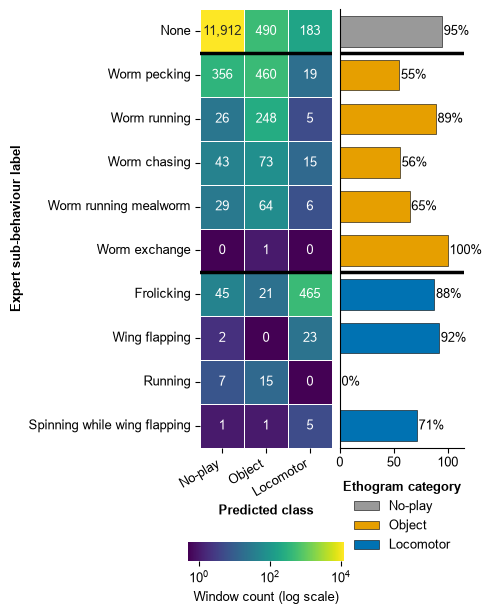

In [ ]:
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch

BEST_RUN_DIR = f"{EVAL_DIR}/20260916_110657_temporal_cnn2"
DATASET_DIR = "../data/dataset"

# ── Load predictions and labels ─────────────────────────────────
preds = pd.read_csv(f"{BEST_RUN_DIR}/predictions.csv")
lab = pd.read_parquet(f"{DATASET_DIR}/labels.parquet")
lab = lab[lab["behav_label"] != "social"].reset_index(drop=True)

merged = preds.merge(
    lab[["video_id", "bird_id", "window", "behav", "behav_label"]],
    on=["video_id", "bird_id", "window"],
)
assert len(merged) == len(preds), "merge lost rows"

merged["sub_behav"] = merged["behav"].str.split(",").str[0].str.strip()

CLASS_ORDER_B = ["none", "worm", "locomotor"]
CLASS_SHORT = {"none": "No-play", "worm": "Object", "locomotor": "Locomotor"}
CLASS_COL_B = {"none": "#999999", "worm": "#E69F00", "locomotor": "#0072B2"}

# SUB_NICE = {
#     "none": "No-play",
#     "Worm pecking": "Pecking",
#     "Worm running": "Running",
#     "Worm chasing": "Chasing",
#     "Worm running mealworm": "Run+mealworm",
#     "Worm exchange": "Exchange",
#     "Frolicking": "Frolicking",
#     "Wing flapping": "Wing flapping",
#     "Running": "Running",
#     "Spinning while wing flapping": "Spin+wing flap",
# }

SUB_PARENT = {}
for s in merged["sub_behav"].unique():
    SUB_PARENT[s] = merged.loc[merged["sub_behav"] == s, "behav_label"].iloc[0]

sub_order = []
for cls in CLASS_ORDER_B:
    subs = [s for s in merged["sub_behav"].unique() if SUB_PARENT[s] == cls]
    subs.sort(key=lambda s: -(merged["sub_behav"] == s).sum())
    sub_order.extend(subs)

# ── Raw count matrix ────────────────────────────────────────────
n_sub = len(sub_order)
heatmap_raw = np.zeros((n_sub, len(CLASS_ORDER_B)), dtype=int)
counts = np.zeros(n_sub, dtype=int)
for i, s in enumerate(sub_order):
    mask_s = merged["sub_behav"] == s
    counts[i] = mask_s.sum()
    for j, c in enumerate(CLASS_ORDER_B):
        heatmap_raw[i, j] = (merged.loc[mask_s, "pred_label"] == c).sum()

recall_sub = np.array([
    heatmap_raw[i, CLASS_ORDER_B.index(SUB_PARENT[s])] / counts[i]
    for i, s in enumerate(sub_order)
])

# ── Plot using JointGrid ───────────────────────────────────────
y_labels = ["None" if s == "none" else s for s in sub_order]
x_labels = [CLASS_SHORT[c] for c in CLASS_ORDER_B]

annot_df = pd.DataFrame(heatmap_raw, index=y_labels, columns=x_labels)
color_df = pd.DataFrame(
    np.where(heatmap_raw > 0, heatmap_raw, 0.5).astype(float),
    index=y_labels,
    columns=x_labels,
)

with plt.style.context(".matplotlib/paper.mplstyle"):
    grid = sns.JointGrid(height=8, ratio=5, space=0)

    # Center: heatmap
    sns.heatmap(
        color_df,
        ax=grid.ax_joint,
        annot=annot_df,
        fmt=",d",
        square=True,
        cmap="viridis",
        norm=LogNorm(vmin=0.5, vmax=heatmap_raw.max()),
        linewidths=0.5,
        linecolor="white",
        cbar_kws={
            "label": "Window count (log scale)",
            "orientation": "horizontal",
            "pad": 0.15,
            "aspect": 8,
            "shrink": 0.25,
        },
    )
    grid.ax_joint.set_xlabel("Predicted class", fontweight="bold")
    grid.ax_joint.set_ylabel("Expert sub-behaviour label", fontweight="bold")
    grid.ax_joint.set_xticklabels(
        grid.ax_joint.get_xticklabels(), rotation=30, ha="right"
    )

    # Group boundaries
    group_boundaries = [
        i
        for i in range(1, n_sub)
        if SUB_PARENT[sub_order[i]] != SUB_PARENT[sub_order[i - 1]]
    ]
    for boundary in group_boundaries:
        grid.ax_joint.axhline(boundary, color="black", linewidth=2.5)

    # Right margin: recall bars (offset by 0.5 to align with heatmap cell centers)
    bar_colors = [CLASS_COL_B[SUB_PARENT[s]] for s in sub_order]
    grid.ax_marg_y.barh(
        np.arange(n_sub) + 0.5,
        recall_sub * 100,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.4,
        height=0.7,
    )
    grid.ax_marg_y.set_xlim(0, 115)
    grid.ax_marg_y.set_xlabel("Recall (%)", fontweight="bold")
    grid.ax_marg_y.set_ylim(grid.ax_joint.get_ylim())

    for boundary in group_boundaries:
        grid.ax_marg_y.axhline(boundary, color="black", linewidth=2.5)

    for i, recall in enumerate(recall_sub):
        grid.ax_marg_y.text(
            recall * 100 + 1.5, i + 0.5, f"{recall:.0%}", ha="left", va="center"
        )

    handles = [
        Patch(facecolor=CLASS_COL_B[c], edgecolor="black", linewidth=0.4)
        for c in CLASS_ORDER_B
    ]
    grid.ax_marg_y.legend(
        handles,
        [CLASS_SHORT[c] for c in CLASS_ORDER_B],
        title="Ethogram category",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        frameon=False,
        columnspacing=0.5,
        title_fontproperties={"weight": "bold"},
    )

    # Hide the top margin (not needed)
    grid.ax_marg_x.set_visible(False)

    sns.despine(ax=grid.ax_marg_y, bottom=False)
    grid.figure.canvas.draw()
    joint_pos = grid.ax_joint.get_position()
    marg_pos = grid.ax_marg_y.get_position()
    grid.ax_marg_y.set_position([
        marg_pos.x0,
        joint_pos.y0,
        marg_pos.width,
        joint_pos.height,
    ])
    grid.ax_marg_y.set_position([
        joint_pos.x1 + 0.01,  # small fixed gap from heatmap right edge
        joint_pos.y0,
        marg_pos.width,
        joint_pos.height,
    ])
    grid.ax_marg_y.set_ylim(grid.ax_joint.get_ylim())
    grid.ax_marg_y.tick_params(left=False, labelleft=False)
    grid.ax_marg_y.set_xlabel("Recall (%)", fontweight="bold")
    grid.ax_marg_y.tick_params(bottom=True, labelbottom=True)
    if save_output:
        plt.savefig(OUT_IMG / "fig3_heatmap.pdf", dpi=300)
        plt.savefig(OUT_IMG / "fig3_heatmap.png", dpi=300)
    plt.show()

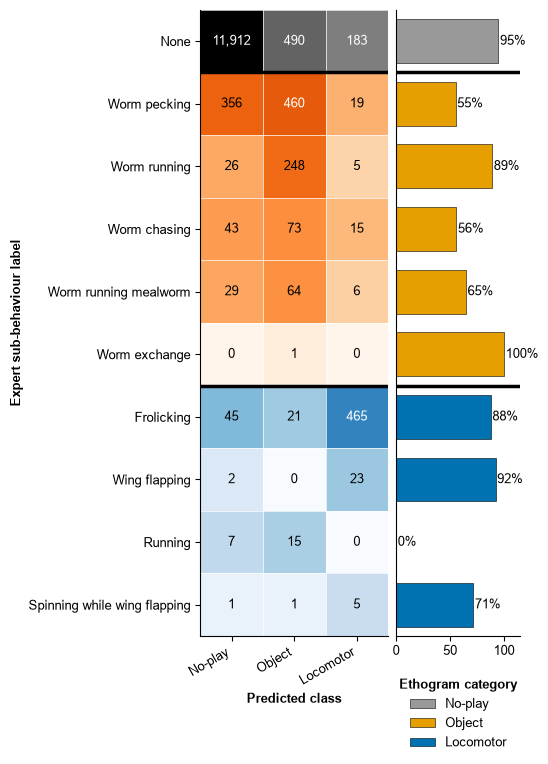

In [ ]:
# ── Panel B v2: per-group colormaps (Greys / Oranges / Blues) ───
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
import matplotlib.cm as cm

# Colormap per parent class (row group)
GROUP_CMAP = {"none": cm.Greys, "worm": cm.Oranges, "locomotor": cm.Blues}
norm = LogNorm(vmin=0.5, vmax=heatmap_raw.max())

# Build RGBA image: each row uses its parent class's colormap
rgba = np.zeros((n_sub, len(CLASS_ORDER_B), 4))
for i, s in enumerate(sub_order):
    cmap = GROUP_CMAP[SUB_PARENT[s]]
    for j in range(len(CLASS_ORDER_B)):
        val = max(heatmap_raw[i, j], 0.5)
        rgba[i, j] = cmap(norm(val))

with plt.style.context(".matplotlib/paper.mplstyle"):
    grid = sns.JointGrid(height=8, ratio=5, space=0)

    ax = grid.ax_joint
    ax.imshow(rgba, aspect="equal", origin="upper", interpolation="nearest")

    # Cell grid lines
    for i in range(n_sub + 1):
        ax.axhline(i - 0.5, color="white", linewidth=0.5)
    for j in range(len(CLASS_ORDER_B) + 1):
        ax.axvline(j - 0.5, color="white", linewidth=0.5)

    # Integer annotations
    for i in range(n_sub):
        for j in range(len(CLASS_ORDER_B)):
            val = heatmap_raw[i, j]
            lum = 0.299 * rgba[i, j, 0] + 0.587 * rgba[i, j, 1] + 0.114 * rgba[i, j, 2]
            color = "white" if lum < 0.5 else "black"
            ax.text(
                j, i, f"{val:,d}", ha="center", va="center", fontsize=9, color=color
            )

    # Axis labels
    y_labels = ["None" if s == "none" else s for s in sub_order]
    x_labels = [CLASS_SHORT[c] for c in CLASS_ORDER_B]
    ax.set_xticks(range(len(CLASS_ORDER_B)))
    ax.set_xticklabels(x_labels, rotation=30, ha="right")
    ax.set_yticks(range(n_sub))
    ax.set_yticklabels(y_labels)
    ax.set_xlabel("Predicted class", fontweight="bold")
    ax.set_ylabel("Expert sub-behaviour label", fontweight="bold")

    # Group boundaries
    group_boundaries = [
        i
        for i in range(1, n_sub)
        if SUB_PARENT[sub_order[i]] != SUB_PARENT[sub_order[i - 1]]
    ]
    for boundary in group_boundaries:
        ax.axhline(boundary - 0.5, color="black", linewidth=2.5)

    # Single colorbar (white→black, log scale)
    sm = cm.ScalarMappable(cmap=cm.Greys, norm=norm)
    sm.set_array([])
    # cax = grid.figure.add_axes([
    #     joint_pos.x0, joint_pos.y0 - 0.12,  # left-aligned, just below
    #     joint_pos.width, 0.015,
    # ])
    # cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
    # cb.set_label("Count (log scale)", fontsize=8)
    # cb.ax.tick_params(labelsize=7)

    # ── Right margin: recall bars ───────────────────────────────
    bar_colors = [CLASS_COL_B[SUB_PARENT[s]] for s in sub_order]
    grid.ax_marg_y.barh(
        np.arange(n_sub),
        recall_sub * 100,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.4,
        height=0.7,
    )
    grid.ax_marg_y.set_xlim(0, 115)
    grid.ax_marg_y.set_xlabel("Recall (%)", fontweight="bold")

    for boundary in group_boundaries:
        grid.ax_marg_y.axhline(boundary - 0.5, color="black", linewidth=2.5)

    for i, recall in enumerate(recall_sub):
        grid.ax_marg_y.text(
            recall * 100 + 1.5, i, f"{recall:.0%}", ha="left", va="center", fontsize=9
        )

    handles = [
        Patch(facecolor=CLASS_COL_B[c], edgecolor="black", linewidth=0.4)
        for c in CLASS_ORDER_B
    ]
    grid.ax_marg_y.legend(
        handles,
        [CLASS_SHORT[c] for c in CLASS_ORDER_B],
        title="Ethogram category",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        frameon=False,
        columnspacing=0.5,
        title_fontproperties={"weight": "bold"},
    )

    grid.ax_marg_x.set_visible(False)
    sns.despine(ax=grid.ax_marg_y, bottom=False)

    # Align bar axes to heatmap after square rendering
    grid.figure.canvas.draw()
    grid.ax_marg_y.set_xlabel("Recall (%)", fontweight="bold")
    joint_pos = grid.ax_joint.get_position()
    marg_pos = grid.ax_marg_y.get_position()
    grid.ax_marg_y.set_position([
        joint_pos.x1 + 0.01,
        joint_pos.y0,
        marg_pos.width,
        joint_pos.height,
    ])
    grid.ax_marg_y.set_ylim(grid.ax_joint.get_ylim())
    grid.ax_marg_y.tick_params(left=False, labelleft=False)
    grid.ax_marg_y.tick_params(bottom=True, labelbottom=True)

    if save_output:
        plt.savefig(OUT_IMG / "fig3_heatmap_v2.pdf", bbox_inches="tight", dpi=300)
        plt.savefig(OUT_IMG / "fig3_heatmap_v2.png", bbox_inches="tight", dpi=300)
    plt.show()

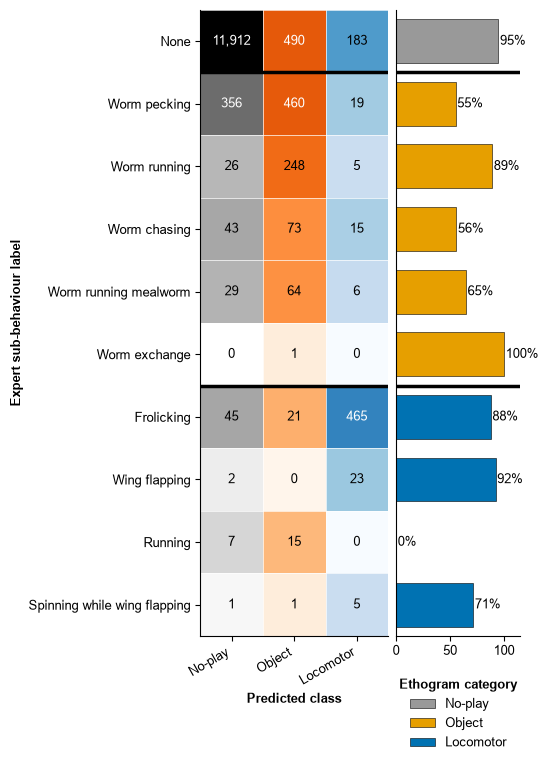

In [ ]:
# ── Panel B v2: per-column colormaps (Greys / Oranges / Blues) ──
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
import matplotlib.cm as cm

COL_CMAPS = [cm.Greys, cm.Oranges, cm.Blues]  # one per predicted class
norm = LogNorm(vmin=0.5, vmax=heatmap_raw.max())

# Build RGBA image: each column uses its own colormap
rgba = np.zeros((n_sub, len(CLASS_ORDER_B), 4))
for j in range(len(CLASS_ORDER_B)):
    for i in range(n_sub):
        val = max(heatmap_raw[i, j], 0.5)
        rgba[i, j] = COL_CMAPS[j](norm(val))

with plt.style.context(".matplotlib/paper.mplstyle"):
    grid = sns.JointGrid(height=8, ratio=5, space=0)

    ax = grid.ax_joint
    ax.imshow(rgba, aspect="equal", origin="upper", interpolation="nearest")

    # Cell grid lines
    for i in range(n_sub + 1):
        ax.axhline(i - 0.5, color="white", linewidth=0.5)
    for j in range(len(CLASS_ORDER_B) + 1):
        ax.axvline(j - 0.5, color="white", linewidth=0.5)

    # Integer annotations
    for i in range(n_sub):
        for j in range(len(CLASS_ORDER_B)):
            val = heatmap_raw[i, j]
            # Pick white text on dark cells, black on light
            lum = 0.299 * rgba[i, j, 0] + 0.587 * rgba[i, j, 1] + 0.114 * rgba[i, j, 2]
            color = "white" if lum < 0.5 else "black"
            ax.text(
                j, i, f"{val:,d}", ha="center", va="center", fontsize=9, color=color
            )

    # Axis labels
    y_labels = ["None" if s == "none" else s for s in sub_order]
    x_labels = [CLASS_SHORT[c] for c in CLASS_ORDER_B]
    ax.set_xticks(range(len(CLASS_ORDER_B)))
    ax.set_xticklabels(x_labels, rotation=30, ha="right")
    ax.set_yticks(range(n_sub))
    ax.set_yticklabels(y_labels)
    ax.set_xlabel("Predicted class", fontweight="bold")
    ax.set_ylabel("Expert sub-behaviour label", fontweight="bold")

    # Group boundaries
    group_boundaries = [
        i
        for i in range(1, n_sub)
        if SUB_PARENT[sub_order[i]] != SUB_PARENT[sub_order[i - 1]]
    ]
    for boundary in group_boundaries:
        ax.axhline(boundary - 0.5, color="black", linewidth=2.5)

    # Colorbars — one per column, horizontal below the heatmap
    # for j, (cmap, cls) in enumerate(zip(COL_CMAPS, CLASS_ORDER_B)):
    #     sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    #     sm.set_array([])
    #     cax = fig.add_axes([0.15 + j * 0.22, -0.02, 0.18, 0.015])
    # cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
    # cb.set_label(CLASS_SHORT[cls], fontsize=8)
    # cb.ax.tick_params(labelsize=7)

    # ── Right margin: recall bars ───────────────────────────────
    bar_colors = [CLASS_COL_B[SUB_PARENT[s]] for s in sub_order]
    grid.ax_marg_y.barh(
        np.arange(n_sub),
        recall_sub * 100,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.4,
        height=0.7,
    )
    grid.ax_marg_y.set_xlim(0, 115)
    grid.ax_marg_y.set_xlabel("Recall (%)", fontweight="bold")

    for boundary in group_boundaries:
        grid.ax_marg_y.axhline(boundary - 0.5, color="black", linewidth=2.5)

    for i, recall in enumerate(recall_sub):
        grid.ax_marg_y.text(
            recall * 100 + 1.5, i, f"{recall:.0%}", ha="left", va="center", fontsize=9
        )

    handles = [
        Patch(facecolor=CLASS_COL_B[c], edgecolor="black", linewidth=0.4)
        for c in CLASS_ORDER_B
    ]
    grid.ax_marg_y.legend(
        handles,
        [CLASS_SHORT[c] for c in CLASS_ORDER_B],
        title="Ethogram category",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        frameon=False,
        columnspacing=0.5,
        title_fontproperties={"weight": "bold"},
    )

    grid.ax_marg_x.set_visible(False)
    sns.despine(ax=grid.ax_marg_y, bottom=False)

    # Align bar axes to heatmap after square rendering
    grid.figure.canvas.draw()
    joint_pos = grid.ax_joint.get_position()
    marg_pos = grid.ax_marg_y.get_position()
    grid.ax_marg_y.set_position([
        joint_pos.x1 + 0.01,
        joint_pos.y0,
        marg_pos.width,
        joint_pos.height,
    ])
    grid.ax_marg_y.set_ylim(grid.ax_joint.get_ylim())
    grid.ax_marg_y.tick_params(left=False, labelleft=False)
    grid.ax_marg_y.set_xlabel("Recall (%)", fontweight="bold")
    grid.ax_marg_y.tick_params(bottom=True, labelbottom=True)

    if save_output:
        plt.savefig(OUT_IMG / "fig3_heatmap_v3.pdf", bbox_inches="tight", dpi=300)
        plt.savefig(OUT_IMG / "fig3_heatmap_v3.png", bbox_inches="tight", dpi=300)
    plt.show()

## Panel c: SHAP analysis (V-JEPA 2.1 best model)

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path

BEST_RUN = Path(f"{EVAL_DIR}/20260916_110657_temporal_cnn2")
DATASET_DIR = Path("../data/dataset")
N_SEGMENTS = 24
CLASS_ORDER = ["none", "worm", "locomotor"]
N_CLASSES = len(CLASS_ORDER)


# ── Model (just enough to get pre-head activations) ─────────────
class GatedAttentionPool(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.gate_fc = nn.Linear(d, 1)

    def forward(self, x):
        w = torch.softmax(self.gate_fc(x), dim=1)
        return (w * x).sum(dim=1)


class TemporalCNNv2(nn.Module):
    def __init__(
        self, d_input, n_classes, d_hidden=128, dropout=0.0, d_flat=0, d_bottleneck=256
    ):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(d_input, d_bottleneck), nn.GELU())
        self.conv = nn.Conv1d(d_bottleneck, d_hidden, kernel_size=3, padding=1)
        self.pool = GatedAttentionPool(d_hidden)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(d_hidden + d_flat, n_classes)

    def forward(self, x, flat=None):
        x = self.proj(x)
        x = x.transpose(1, 2)
        x = F.gelu(self.conv(x))
        x = x.transpose(1, 2)
        x = self.pool(x)
        if flat is not None:
            x = torch.cat([x, flat], dim=-1)
        return self.head(self.drop(x))

    @torch.no_grad()
    def prehead(self, x, flat=None):
        """Return the (d_hidden + d_flat,) vector just before the head."""
        x = self.proj(x)
        x = x.transpose(1, 2)
        x = F.gelu(self.conv(x))
        x = x.transpose(1, 2)
        x = self.pool(x)
        if flat is not None:
            x = torch.cat([x, flat], dim=-1)
        return x


# ── Load dataset ────────────────────────────────────────────────
labels_df = pd.read_parquet(DATASET_DIR / "labels.parquet")
exclude = "social"
label_order = [l for l in CLASS_ORDER if l != exclude]
mask = labels_df["behav_label"] != exclude
labels_df = labels_df[mask].reset_index(drop=True)

keys = list(zip(labels_df["video_id"], labels_df["bird_id"], labels_df["window"]))
y = np.array([CLASS_ORDER.index(l) for l in labels_df["behav_label"]])

# Windowed features → z-score
feat_df = pd.read_parquet(DATASET_DIR / "features_windowed.parquet")
feat_df = feat_df[mask.values].reset_index(drop=True)
skip_cols = {"video_id", "bird_id", "window", "n_frames"}
feat_cols = [c for c in feat_df.columns if c not in skip_cols]
feat_vals = (
    feat_df[feat_cols].fillna(feat_df[feat_cols].median()).values.astype(np.float32)
)
feat_mean = feat_vals.mean(axis=0)
feat_std = feat_vals.std(axis=0).clip(min=1e-8)
flat = torch.tensor((feat_vals - feat_mean) / feat_std, dtype=torch.float32)

# Temporal embeddings → segment-pool
emb_dict = torch.load(
    DATASET_DIR / "embeddings_vjepa21_vitl_temporal.pt",
    weights_only=False,
)


def adaptive_segment_pool1d(x, n_segments):
    x = x.unsqueeze(0).transpose(1, 2)
    x = F.adaptive_avg_pool1d(x, n_segments)
    return x.transpose(1, 2).squeeze(0)


emb = torch.stack([
    adaptive_segment_pool1d(emb_dict[k].float(), N_SEGMENTS) for k in keys
])
del emb_dict

# Cage IDs for LOCO folds
cage_ids = np.array([vid[:2] for vid in labels_df["video_id"]])

print(f"Samples: {len(labels_df)}, Embedding: {emb.shape}, Flat features: {flat.shape}")
print(f"Cages: {sorted(set(cage_ids))}")

Samples: 14515, Embedding: torch.Size([14515, 24, 1024]), Flat features: torch.Size([14515, 171])
Cages: [np.str_('C1'), np.str_('C2'), np.str_('C3'), np.str_('C4'), np.str_('C5')]


In [10]:
import shap


def load_model(ckpt_path, d_input, n_classes, d_flat):
    """Load a TemporalCNNv2 from a Lightning checkpoint."""
    model = TemporalCNNv2(d_input, n_classes, d_flat=d_flat)
    sd = torch.load(ckpt_path, weights_only=True, map_location="cpu")["state_dict"]
    # Strip "backbone." prefix from Lightning's state dict
    sd = {
        k.replace("backbone.", ""): v
        for k, v in sd.items()
        if k.startswith("backbone.")
    }
    model.load_state_dict(sd)
    model.eval()
    return model


def get_centered_head(model):
    """Extract head W, b and center across classes."""
    W = model.head.weight.detach().numpy()
    b = model.head.bias.detach().numpy()
    W_c = W - W.mean(axis=0, keepdims=True)
    b_c = b - b.mean()
    return W_c, b_c


def cache_prehead(model, emb_fold, flat_fold):
    """Run the model up to the head and return pre-head activations as numpy."""
    with torch.no_grad():
        return model.prehead(emb_fold, flat_fold).numpy()


# ── SHAP over LOCO folds ───────────────────────────────────────
folds = sorted(set(cage_ids))
fold_dirs = sorted(BEST_RUN.glob("fold_*"))
d_input = emb.shape[-1]  # 1024
d_flat = flat.shape[-1]  # 171

all_shap = np.zeros(
    (len(y), N_CLASSES, d_flat + 128), dtype=np.float32
)  # will fill per fold

for fold_idx, fold_dir in enumerate(fold_dirs):
    cage = fold_dir.name.split("_")[-1]  # e.g. "C1"
    held_out = cage_ids == cage
    ckpt = sorted((fold_dir / "checkpoints").glob("*.ckpt"))[0]

    model = load_model(ckpt, d_input, N_CLASSES, d_flat)
    W_c, b_c = get_centered_head(model)

    C_test = cache_prehead(model, emb[held_out], flat[held_out])
    d_emb = C_test.shape[1] - d_flat

    bg = shap.maskers.Independent(C_test, max_samples=len(C_test))
    sv = shap.LinearExplainer((W_c, b_c), bg).shap_values(C_test)
    # sv shape: (n_held_out, d_prehead, n_classes)
    all_shap[held_out] = sv.transpose(0, 2, 1)  # → (n, n_classes, d_prehead)

    print(
        f"  Fold {fold_idx} ({cage}): {held_out.sum()} windows, prehead dim {C_test.shape[1]}"
    )

print(f"Done. SHAP values shape: {all_shap.shape}")

  Fold 0 (C1): 3018 windows, prehead dim 299
  Fold 1 (C2): 2895 windows, prehead dim 299
  Fold 2 (C3): 2885 windows, prehead dim 299
  Fold 3 (C4): 2891 windows, prehead dim 299
  Fold 4 (C5): 2826 windows, prehead dim 299
Done. SHAP values shape: (14515, 3, 299)


In [11]:
# ── Group SHAP by feature category ──────────────────────────────
d_emb = 128


# Concept family for each mask feature column
def concept_of(col_name):
    """'mask_area_mean' → 'mask_area', 'velocity_std' → 'velocity', etc."""
    parts = col_name.rsplit("_", 1)
    return parts[0] if len(parts) == 2 else col_name


feat_concepts = [concept_of(c) for c in feat_cols]
unique_concepts = list(dict.fromkeys(feat_concepts))

CONCEPT_NICE = {
    "mask_area": "Mask area",
    "aspect_ratio": "Aspect ratio",
    "velocity": "Velocity",
    "solidity": "Solidity",
    "elongation": "Elongation",
    "orientation": "Orientation",
    "eccentricity": "Eccentricity",
    "perimeter": "Perimeter",
    "circularity": "Circularity",
    "mean_dist_to_other": "Proximity (mean)",
    "min_dist_to_other": "Proximity (min)",
    "acceleration": "Acceleration",
    "turning_angle": "Turning angle",
    "velocity_autocorr": "Velocity autocorr.",
    "area_change_rate": "Area change rate",
    "dist_change_rate": "Dist. change rate",
    "elongation_change": "Elongation change",
    "orientation_velocity": "Orientation velocity",
    "solidity_change": "Solidity change",
}

# Split SHAP: embedding dims vs each concept family
# all_shap is (n, n_classes, d_prehead) where d_prehead = d_emb + d_flat
shap_emb = all_shap[:, :, :d_emb]  # (n, C, 128)
shap_flat = all_shap[:, :, d_emb:]  # (n, C, 171)

# For each group: sum signed SHAP within group, then |magnitude|
# Group 0: Embedding, Group 1: all morphokinematic features, then individual families
group_labels = ["Embedding", "Morphok. features\n(composite)"]
group_mag = [
    np.abs(shap_emb.sum(axis=2)),  # (n, C) — embedding
    np.abs(shap_flat.sum(axis=2)),  # (n, C) — all 171 features combined
]

for concept in unique_concepts:
    col_mask = np.array([c == concept for c in feat_concepts])
    signed_sum = shap_flat[:, :, col_mask].sum(axis=2)  # (n, C)
    group_mag.append(np.abs(signed_sum))
    group_labels.append(CONCEPT_NICE.get(concept, concept))

group_mag = np.stack(group_mag, axis=0)  # (n_groups, n, C)

# Per-cage means → mean of cage means ± SEM
unique_cages = sorted(set(cage_ids))
n_cages = len(unique_cages)
cage_means = np.zeros((len(group_labels), n_cages, N_CLASSES), dtype=np.float32)
for ci, cage in enumerate(unique_cages):
    cage_mask = cage_ids == cage
    cage_means[:, ci, :] = group_mag[:, cage_mask, :].mean(axis=1)

mean_shap = cage_means.mean(axis=1)  # (n_groups, C)
sem_shap = cage_means.std(axis=1, ddof=1) / np.sqrt(n_cages)  # (n_groups, C)

print("Feature groups: mean |SHAP| ± SEM (across cage means)")
for i, label in enumerate(group_labels):
    vals = "  ".join(
        f"{CLASS_ORDER[c]}: {mean_shap[i, c]:.3f}±{sem_shap[i, c]:.3f}"
        for c in range(N_CLASSES)
    )
    print(f"  {label:25s}  {vals}")

# Sort individual families by overall mean importance (indices 2+ in group_labels)
family_order = np.argsort(-mean_shap[2:].mean(axis=1)) + 2
plot_order = [0, 1] + family_order.tolist()  # embedding, features, then families ranked

Feature groups: mean |SHAP| ± SEM (across cage means)
  Embedding                  none: 0.388±0.021  worm: 0.371±0.036  locomotor: 0.235±0.048
  Morphok. features
(composite)  none: 0.210±0.020  worm: 0.240±0.016  locomotor: 0.213±0.011
  Mask area                  none: 0.037±0.006  worm: 0.133±0.012  locomotor: 0.128±0.007
  Aspect ratio               none: 0.031±0.004  worm: 0.037±0.005  locomotor: 0.033±0.004
  Velocity                   none: 0.053±0.013  worm: 0.040±0.007  locomotor: 0.031±0.004
  Acceleration               none: 0.037±0.003  worm: 0.053±0.005  locomotor: 0.038±0.007
  Area change rate           none: 0.039±0.003  worm: 0.038±0.006  locomotor: 0.027±0.002
  Orientation velocity       none: 0.068±0.013  worm: 0.064±0.014  locomotor: 0.046±0.003
  Solidity change            none: 0.073±0.010  worm: 0.081±0.009  locomotor: 0.027±0.005
  Elongation change          none: 0.039±0.005  worm: 0.048±0.004  locomotor: 0.030±0.004
  Turning angle              none: 0.025±0

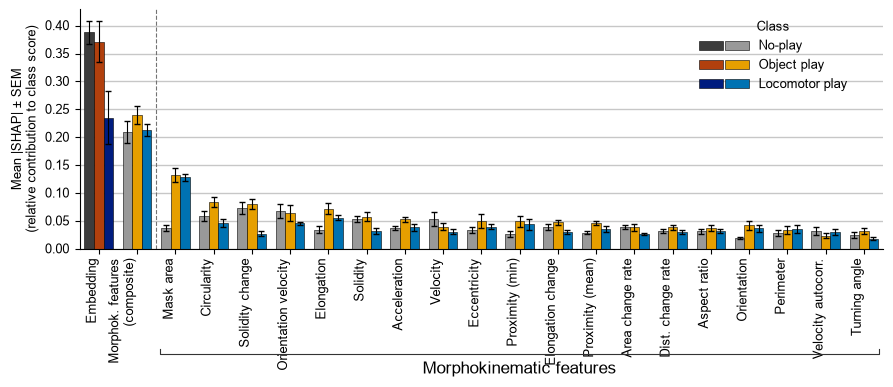

In [12]:
# ── Plot: mean |SHAP| by feature category ──────────────────────
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

CLASS_NICE = {"none": "No-play", "worm": "Object play", "locomotor": "Locomotor play"}
CLASS_COL = {"none": "#999999", "worm": "#E69F00", "locomotor": "#0072B2"}
CLASS_COL_DARK = {"none": "#3c3c3c", "worm": "#b1400d", "locomotor": "#001c7f"}

x_labels = [group_labels[i] for i in plot_order]
x = np.arange(len(x_labels))
bar_width = 0.25

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(9, 4.42))

    for c_idx, cls in enumerate(CLASS_ORDER):
        vals = [mean_shap[g, c_idx] for g in plot_order]
        errs = [sem_shap[g, c_idx] for g in plot_order]
        offset = (c_idx - 1) * bar_width

        colors = [CLASS_COL_DARK[cls] if g == 0 else CLASS_COL[cls] for g in plot_order]
        ax.bar(
            x + offset,
            vals,
            bar_width,
            yerr=errs,
            color=colors,
            edgecolor="black",
            linewidth=0.4,
            capsize=2,
            error_kw={"linewidth": 0.8},
        )

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=90, ha="right", fontsize=9)
    ax.set_ylabel("Mean |SHAP| ± SEM\n(relative contribution to class score)")
    ax.axvline(1.5, color="0.45", linewidth=0.8, linestyle="--")

    handles = [
        tuple([
            Patch(facecolor=CLASS_COL_DARK[cls], edgecolor="black", linewidth=0.4),
            Patch(facecolor=CLASS_COL[cls], edgecolor="black", linewidth=0.4),
        ])
        for cls in CLASS_ORDER
    ]
    ax.legend(
        handles,
        [CLASS_NICE[cls] for cls in CLASS_ORDER],
        handler_map={tuple: HandlerTuple(ndivide=None, pad=0.15)},
        frameon=False,
        handlelength=4,
        bbox_to_anchor=(0.97, 1.0),
        title="Class",
    )

    # Bracket under individual feature families
    n_families = len(x_labels) - 2  # skip Embedding + Features (composite)
    x_left = 2 - 0.4
    x_right = len(x_labels) - 1 + 0.4
    bracket_y = -0.44
    tick_h = 0.02
    trans = ax.get_xaxis_transform()
    ax.plot(
        [x_left, x_left, x_right, x_right],
        [bracket_y + tick_h, bracket_y, bracket_y, bracket_y + tick_h],
        transform=trans,
        color="0.2",
        linewidth=0.8,
        clip_on=False,
    )
    ax.text(
        (x_left + x_right) / 2,
        bracket_y - 0.03,
        "Morphokinematic features",
        transform=trans,
        ha="center",
        va="top",
        fontsize=12,
        color="k",
    )
    ax.set_xlim(-0.5, len(x_labels) - 0.5)
    ax.grid(axis="y", linewidth=1, alpha=0.7, zorder=0)
    ax.set_axisbelow(True)
    sns.despine()
    plt.tight_layout()
    if save_output:
        plt.savefig(OUT_IMG / "fig3_shap_feature_groups.pdf", bbox_inches="tight", dpi=300)
    plt.show()